# 

### Load and Explore Dataset

Date: 2026-07-23

Student ID: DAMHAR2570

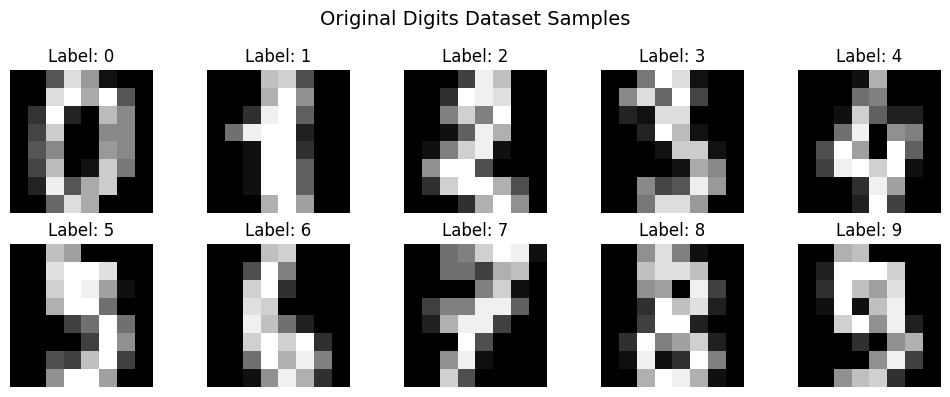

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from datetime import datetime
from IPython.display import display, Markdown
todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "DAMHAR2570"

display(Markdown("### Load and Explore Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Load the Digits dataset
digits = load_digits()
X = digits.images
y = digits.target

# Display the original images 
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i], cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')

plt.suptitle("Original Digits Dataset Samples", fontsize=14)
plt.tight_layout()
plt.show()

### Preprocess the Data

Date: 2026-07-23

Student ID: DAMHAR2570

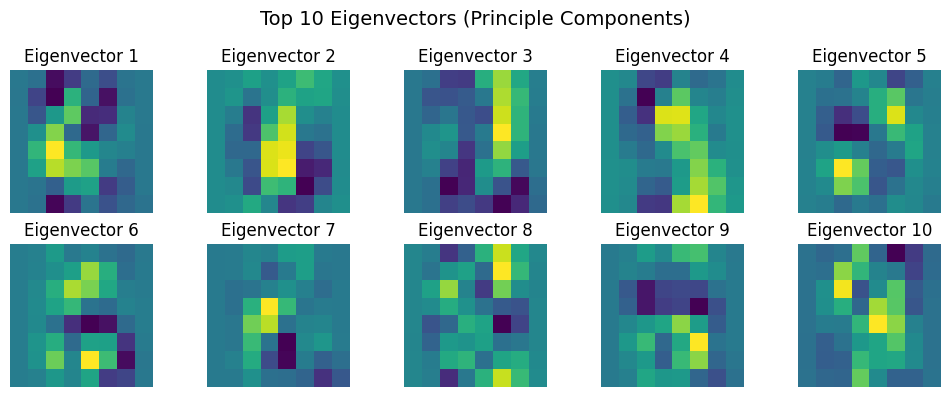

===Data Shapes===
X_train shape: (1078, 8, 8, 1)
y_train shape: (1078, 10)
X_test shape: (719, 8, 8, 1)
y_test shape: (719, 10)


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from tensorflow.keras.utils import to_categorical

display(Markdown("### Preprocess the Data"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

#Extract and displa the eigenvectors using PCA
X_flat = digits.data
pca = PCA(n_components=10)
pca.fit(X_flat)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    eigenvector_img = pca.components_[i].reshape(8, 8)
    ax.imshow(eigenvector_img, cmap='viridis')
    ax.set_title(f"Eigenvector {i+1}")
    ax.axis('off')

plt.suptitle("Top 10 Eigenvectors (Principle Components)", fontsize=14)
plt.tight_layout()
plt.show()

X_cnn = X.reshape(-1, 8, 8, 1)

X_train, X_test, y_train, y_test = train_test_split(X_cnn, y, test_size=0.4, random_state=42)

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print("===Data Shapes===")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train_cat.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test_cat.shape}")


### Construct and Train the CNN Model

Date: 2026-07-23

Student ID: DAMHAR2570

C:\Users\ecpi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



===Model Summary


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 6, 6, 32)            │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 3, 3, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 288)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,466 (76.04 KB)

 Trainable params: 19,466 (76.04 KB)

 Non-trainable params: 0 (0.00 B)


===Training Model===
Epoch 1/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.1689 - loss: 4.6626 - val_accuracy: 0.6250 - val_loss: 1.4321
Epoch 2/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7077 - loss: 1.1468 - val_accuracy: 0.8935 - val_loss: 0.6194
Epoch 3/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8709 - loss: 0.5194 - val_accuracy: 0.9120 - val_loss: 0.3288
Epoch 4/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9456 - loss: 0.2977 - val_accuracy: 0.9352 - val_loss: 0.2397
Epoch 5/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9515 - loss: 0.2140 - val_accuracy: 0.9630 - val_loss: 0.1690
Epoch 6/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9649 - loss: 0.1545 - val_accuracy: 0.9537 - val_loss: 0.1669
Epoch 7/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9837 - loss: 0.1000 - val_accuracy: 0.9722 - val_loss: 0.1412
Epoch 8/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9721 - loss: 0.0989 - val_accur

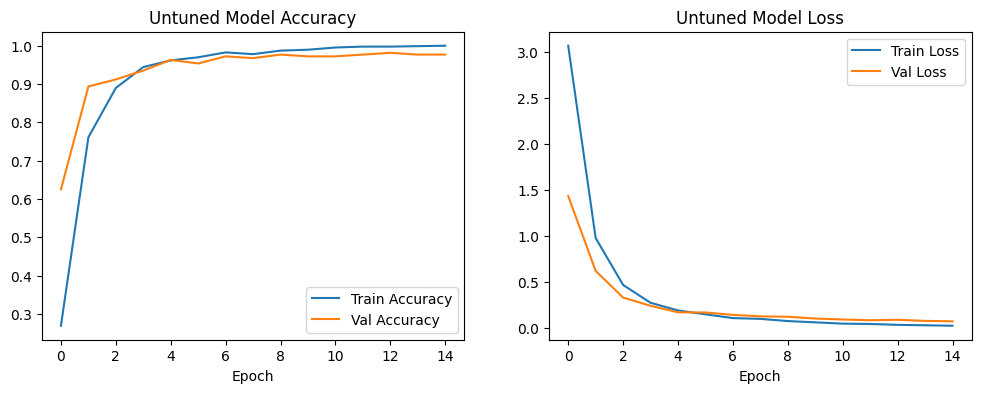

In [3]:
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

display(Markdown("### Construct and Train the CNN Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

#Use sequential function to build the model
model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(8, 8, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])



#Compile the model
model.compile(optimizer='adam',
             loss='categorical_crossentropy',
             metrics=['accuracy'])

print("\n===Model Summary")
model.summary()

print("\n===Training Model===")
history = model.fit(X_train, y_train_cat, epochs=15, validation_split=0.2, batch_size=32)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Untuned Model Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Untuned Model Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()


### Evaluate CNN Model

Date: 2026-07-23

Student ID: DAMHAR2570

Untuned Model - Test Loss: 0.0699
Untuned Model - Test Accuracy 0.9819

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


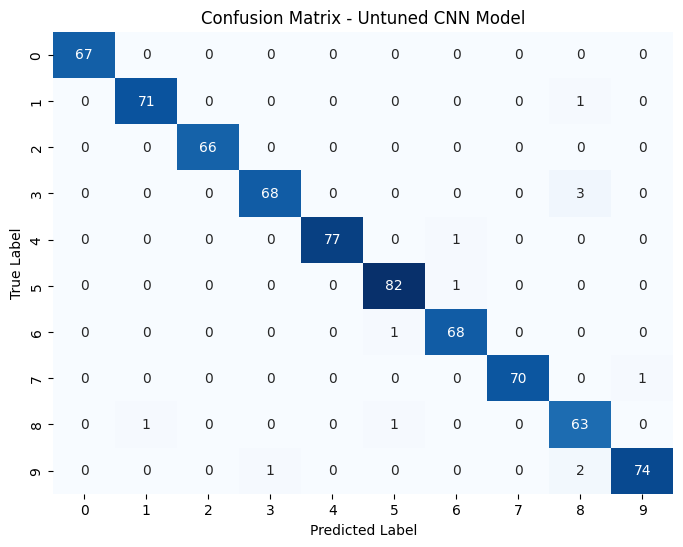

In [4]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

display(Markdown("### Evaluate CNN Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Evaluate model on testing data
loss, accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Untuned Model - Test Loss: {loss:.4f}")
print(f"Untuned Model - Test Accuracy {accuracy:.4f}\n")

# Make predictions on the test data
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_cat, axis=1)

# create a confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Untuned CNN Model')
plt.show()

In [5]:
import keras_tuner as kt

display(Markdown("### Apply Hyperband for CNN Heyperparameter Tuning"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Create a hypermodel using the Sequential function
def build_model(hp):
    tuned_model = Sequential()

    hp_filters = hp.Int('filters', min_value=32, max_value=128, step=32)
    tuned_model.add(Conv2D(hp_filters, kernel_size=(3, 3), activation='relu', input_shape=(8, 8, 1)))

    tuned_model.add(MaxPooling2D(pool_size=(2, 2)))
    tuned_model.add(Flatten())
    hp_units = hp.Int('units', min_value=64, max_value=256, step=64)
    tuned_model.add(Dense(hp_units, activation='relu'))
    tuned_model.add(Dense(10, activation='softmax'))
    tuned_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return tuned_model

tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='keras_tuner_dir',
    project_name='cnn_digits_tuning',
    overwrite=True
)

print("===Starting Hyperparameter Search===")
tuner.search(X_train, y_train_cat, epochs=10, validation_split=0.2, verbose=1)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\n===Optimal Hyperparameters Found===")
print(f"Optimal number of filters in Conv2D: {best_hps.get('filters')}")
print(f"Optimal number of neurons in Dense layer: {best_hps.get('units')}")


Trial 21 Complete [00h 00m 07s]
val_accuracy: 0.9768518805503845

Best val_accuracy So Far: 0.9907407164573669
Total elapsed time: 00h 02m 17s

===Optimal Hyperparameters Found===
Optimal number of filters in Conv2D: 96
Optimal number of neurons in Dense layer: 128


### Apply Optimal Hyperparameters and Evaluate the Tuned CNN Model

Date: 2026-07-23

Student ID: DAMHAR2570

===training Tuned model===
Epoch 1/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.3641 - loss: 2.0584 - val_accuracy: 0.8704 - val_loss: 0.4801
Epoch 2/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9216 - loss: 0.3473 - val_accuracy: 0.8981 - val_loss: 0.2630
Epoch 3/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9689 - loss: 0.1495 - val_accuracy: 0.9722 - val_loss: 0.1131
Epoch 4/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9883 - loss: 0.0800 - val_accuracy: 0.9722 - val_loss: 0.0893
Epoch 5/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9959 - loss: 0.0525 - val_accuracy: 0.9722 - val_loss: 0.0812
Epoch 6/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9898 - loss: 0.0499 - val_accuracy: 0.9815 - val_loss: 0.0621
Epoch 7/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9967 - loss: 0.0271 - val_accuracy: 0.9722 - val_loss: 0.0783
Epoch 8/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9941 - loss: 0.0237 

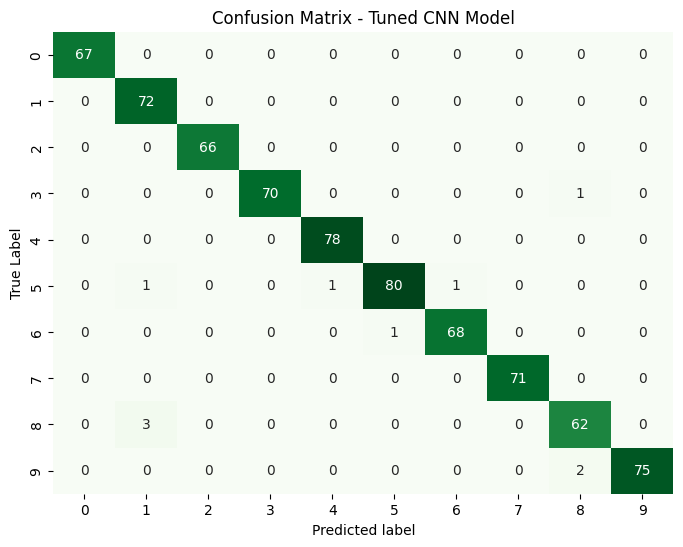

In [6]:
display(Markdown("### Apply Optimal Hyperparameters and Evaluate the Tuned CNN Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

best_model = tuner.hypermodel.build(best_hps)
best_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
print("===training Tuned model===")
tuned_history = best_model.fit(X_train, y_train_cat, epochs=15, validation_split=0.2, batch_size=32)

tuned_loss, tuned_accuracy = best_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\nTuned Model - Test Loss: {tuned_loss:.4f}")
print(f"Tuned Model - test Accuracy: {tuned_accuracy:.4f}\n")

y_pred_tuned = best_model.predict(X_test)
y_pred_tuned_classes = np.argmax(y_pred_tuned, axis=1)

cm_tuned = confusion_matrix(y_true_classes, y_pred_tuned_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.xlabel('Predicted label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Tuned CNN Model')
plt.show()

### Compare Performance of the CNN Models

Date: 2026-07-23

Student ID: DAMHAR2570

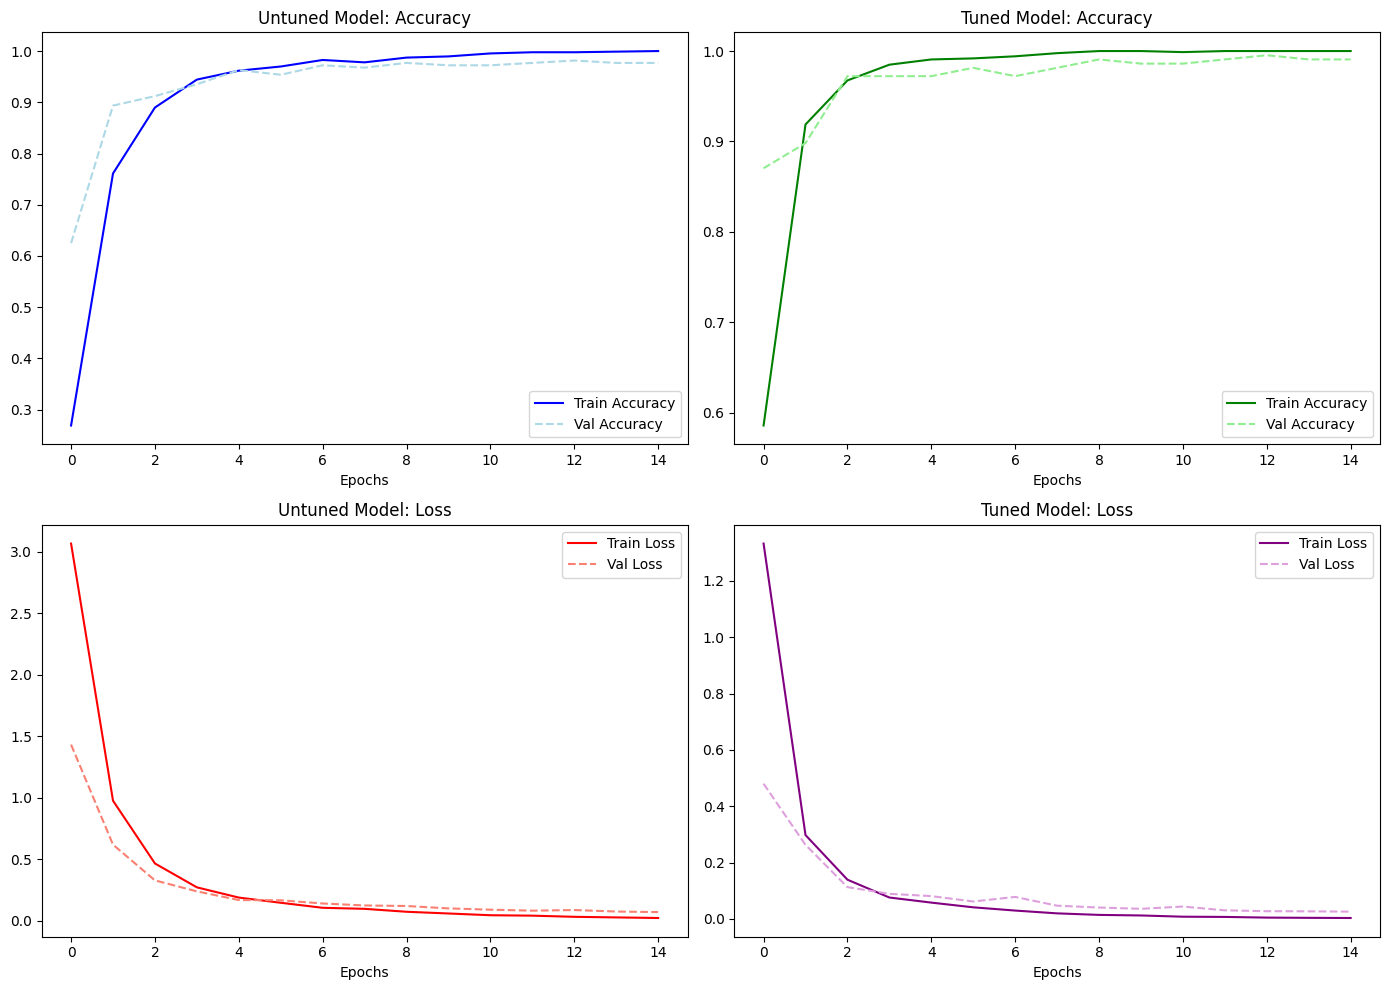

In [7]:
display(Markdown("### Compare Performance of the CNN Models"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

fig, axes =  plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
axes[0, 0].plot(history.history['val_accuracy'], label='Val Accuracy', color='lightblue', linestyle='--')
axes[0, 0].set_title('Untuned Model: Accuracy')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].legend()

axes[0, 1].plot(tuned_history.history['accuracy'], label='Train Accuracy', color='green')
axes[0, 1].plot(tuned_history.history['val_accuracy'], label='Val Accuracy', color='lightgreen', linestyle='--')
axes[0, 1].set_title('Tuned Model: Accuracy')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].legend()

axes[1, 0].plot(history.history['loss'], label='Train Loss', color='red')
axes[1, 0].plot(history.history['val_loss'], label='Val Loss', color='salmon', linestyle='--')
axes[1, 0].set_title('Untuned Model: Loss')
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].legend()

axes[1, 1].plot(tuned_history.history['loss'], label='Train Loss', color='purple')
axes[1, 1].plot(tuned_history.history['val_loss'], label='Val Loss', color='plum', linestyle='--')
axes[1, 1].set_title('Tuned Model: Loss')
axes[1, 1].set_xlabel('Epochs')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

1. How can confusion matrices and training history visualizations be used to evaluate and improve the performance of deep learning models?
   Confusion matrices allow you to see exactly where the model is struggling by breaking down errors by class. It allows you to improve areas of interests by gathering more data to improve performance. Training history visualization reveal the learning behavior of the model over time by identifying overfitting or underfitting to improve the model by using the optimal number of epochs.

2. What optimization techniques were applied to the CNN model? Which model performs better, and what evidence do you have to support your claim?
    Hyperband Search, Adam Optimizer, and Max Pooling were the techniques applied to the CNN model for optimization. The tuned model achieves better testing accuracy than the untuned model however the validation loss of the tuned model was lower showing that it generalizes better on unseen data.